# Лабораторная работа №1

**Тема:** использование нейронных сетей прямого распространения (FNN) для решения задач классификации.

**Вариант 5:** датасет Dry Bean (классификация видов бобов), исследование влияния **learning rate** (0.1, 0.01, 0.001) при фиксированной архитектуре сети и остальных гиперпараметрах.

В ноутбуке:
- загружаем и анализируем датасет Dry Bean;
- подготавливаем признаки для обучения FNN;
- строим и обучаем полносвязную нейросеть;
- проводим серию экспериментов с разными значениями learning rate;
- сравниваем качество и делаем выводы для отчёта.

## 1. Импорт библиотек и настройка окружения

В этой ячейке импортируем все необходимые библиотеки для работы с данными, построения и обучения нейронной сети.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", None)
sns.set(style="ticks", palette="viridis")

## 2. Загрузка и первичный анализ датасета Dry Bean

Загружаем CSV-файл `Dry_Bean.csv`, выводим первые строки, общую информацию о данных, статистические характеристики и распределение классов. Это нужно для описания датасета в отчёте.

In [11]:
data_path = r"c:\\Users\\miros\\Downloads\\Dry_Bean.csv"
data = pd.read_csv(data_path)

print("Первые строки датасета:")
display(data.head())

print("\nИнформация о датасете:")
print(data.info())

print("\nОписание числовых признаков:")
display(data.describe())

print("\nРаспределение классов:")
print(data["Class"].value_counts())

Первые строки датасета:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtyp

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733



Распределение классов:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


## 2.1 Дополнительный анализ и проверка качества данных

На этом этапе выполним более подробный анализ датасета Dry Bean:

- проверим наличие пропусков в каждом столбце;
- найдём явные дубликаты строк;
- оценим распределение числовых признаков и возможные выбросы;
- посмотрим "баланс" классов в выборке в относительных долях.

Это расширенный этап разведочного анализа данных (EDA), необходимый для оценки качества исходного набора данных перед обучением нейронной сети.

In [12]:
# проверка пропусков и дубликатов
print("Проверка пропусков по столбцам:")
missing = data.isna().sum()
display(missing)

print("\nКоличество полностью дублирующих строк:")
print(data.duplicated().sum())

# относительные доли классов (баланс классов)
print("\nОтносительное распределение классов (%):")
class_share = data["Class"].value_counts(normalize=True) * 100
display(class_share.round(2))

Проверка пропусков по столбцам:


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


Количество полностью дублирующих строк:
68

Относительное распределение классов (%):


Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64

### Пояснение к дополнительным графикам

1. **Гистограммы основных числовых признаков**  
   Графики распределений `Area`, `Perimeter`, `AspectRation`, `Eccentricity` позволяют оценить диапазоны значений признаков, наличие скошенности распределений и потенциальных выбросов. Это помогает понять масштаб признаков перед нормализацией и убедиться, что в данных нет аномально некорректных значений.

2. **Тепловая карта корреляций признаков**  
   Тепловая карта показывает парные коэффициенты корреляции между числовыми признаками. Высокие по модулю значения (близкие к 1 или -1) указывают на сильную линейную зависимость между признаками, что может влиять на обучение модели (избыточная информация, мультиколлинеарность). В нашем случае видно, что часть геометрических характеристик бобов (например, площадь, периметр и связанные измерения) ожидаемо коррелируют друг с другом.

3. **Столбчатая диаграмма распределения классов**  
   Диаграмма с количеством объектов каждого класса демонстрирует баланс классов в выборке. Хотя классы представлены не идеально равномерно (например, класс `DERMASON` встречается чаще, чем `BOMBAY`), сильного дисбаланса (полностью доминирующего класса и очень редких классов) нет. Это означает, что задача многоклассовой классификации в данном датасете относительно сбалансирована, и модель может учиться без специальных методов борьбы с дисбалансом (re-sampling, class weights и т.п.).

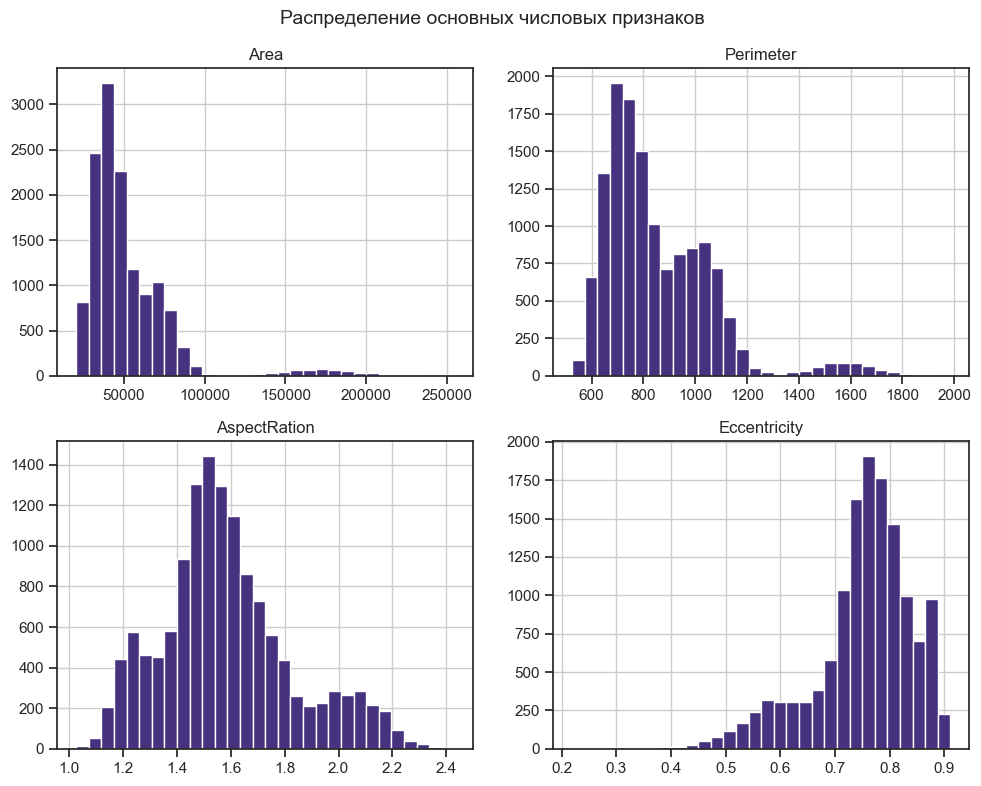

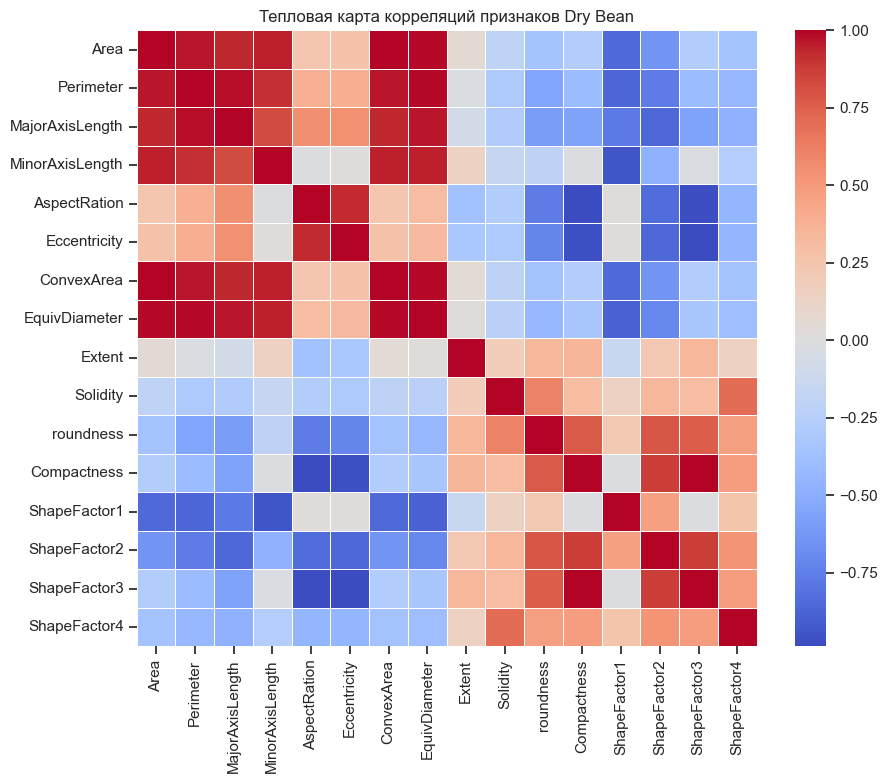

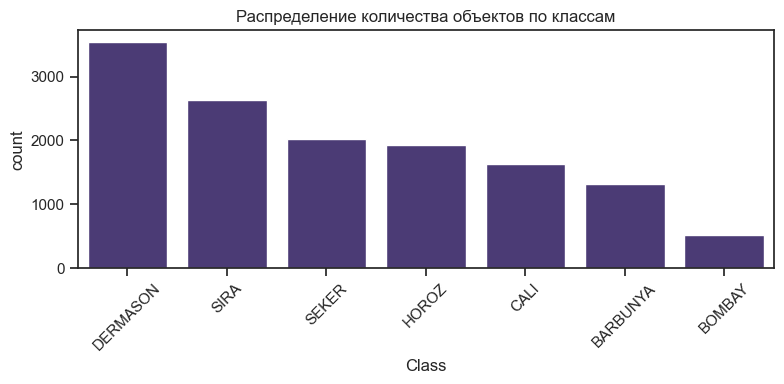

In [13]:
# визуализация распределений некоторых признаков и классов

# гистограммы ключевых числовых признаков
numeric_sample_cols = ["Area", "Perimeter", "AspectRation", "Eccentricity"]

data[numeric_sample_cols].hist(bins=30, figsize=(10, 8))
plt.suptitle("Распределение основных числовых признаков", fontsize=14)
plt.tight_layout()
plt.show()

# тепловая карта корреляций между числовыми признаками
plt.figure(figsize=(10, 8))
correlation_matrix = data.select_dtypes(include=["float64", "int64"]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Тепловая карта корреляций признаков Dry Bean")
plt.show()

# распределение количества объектов по классам (barplot)
plt.figure(figsize=(8, 4))
sns.countplot(x="Class", data=data, order=data["Class"].value_counts().index)
plt.title("Распределение количества объектов по классам")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Подготовка данных для обучения FNN

- отделяем признаки от целевой переменной `Class`;
- кодируем классы метками (LabelEncoder) и затем one-hot вектором (для многоклассовой классификации);
- разбиваем данные на обучающую и тестовую выборки (стратифицировано по классам);
- нормализуем числовые признаки с помощью `StandardScaler`.

Эти шаги составляют этап подготовки данных перед обучением нейронной сети и позволяют привести признаки и целевую переменную к удобному для модели виду.

In [14]:
# отделяем признаки и целевой столбец
feature_cols = [col for col in data.columns if col != "Class"]
X = data[feature_cols].values
y_raw = data["Class"].values

# кодирование классов в целые числа
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_raw)
num_classes = len(label_encoder.classes_)

print("Классы:", label_encoder.classes_)
print("Количество классов:", num_classes)

# one-hot представление целевой переменной
y = keras.utils.to_categorical(y_int, num_classes=num_classes)

# разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_int,
)

# нормализация признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nФормы массивов:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Классы: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Количество классов: 7

Формы массивов:
X_train: (10888, 16)
X_test : (2723, 16)
y_train: (10888, 7)
y_test : (2723, 7)


## 4. Построение модели нейронной сети прямого распространения (FNN)

Создаём функцию `build_model`, которая строит полносвязную нейросеть:
- вход: размерность = число признаков;
- 2 скрытых слоя по 64 нейрона с активацией ReLU;
- выходной слой с количеством нейронов, равным числу классов, и softmax-активацией;
- оптимизатор Adam с настраиваемым `learning_rate`;
- функция потерь `categorical_crossentropy`, метрика `accuracy`.

Архитектура фиксирована, а в дальнейшем мы будем менять только значение `learning rate`.

In [15]:
def build_model(input_dim: int, num_classes: int, learning_rate: float) -> keras.Model:
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


# проверим краткое описание модели для одного из значений learning rate
test_model = build_model(input_dim=X_train.shape[1], num_classes=num_classes, learning_rate=0.001)
test_model.summary()

c:\Users\miros\PycharmProjects\ml\.venv_tf\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,703 (22.28 KB)

 Trainable params: 5,703 (22.28 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Эксперимент: влияние значения learning rate

В соответствии с вариантом 5 исследуем влияние следующих значений `learning rate`:
- 0.1
- 0.01
- 0.001

Для каждого значения:
- создаём и обучаем модель с одинаковой архитектурой и числом эпох;
- фиксируем одинаковый `batch_size` и `random_state`;
- оцениваем качество на тестовой выборке (accuracy и loss);
- сохраняем историю обучения для построения графиков.

In [16]:
learning_rates = [0.1, 0.01, 0.001]
results = {}
histories = {}

EPOCHS = 30
BATCH_SIZE = 64

for lr in learning_rates:
    print(f"\n==== Обучение модели с learning rate = {lr} ====")
    model = build_model(input_dim=X_train.shape[1], num_classes=num_classes, learning_rate=lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        verbose=1,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Точность на тесте при lr={lr}: {test_acc:.4f}, loss={test_loss:.4f}")

    results[lr] = {"test_acc": test_acc, "test_loss": test_loss}
    histories[lr] = history

print("\n=== Сводка результатов по learning rate ===")
for lr in learning_rates:
    print(
        f"lr={lr}: "
        f"test_accuracy={results[lr]['test_acc']:.4f}, "
        f"test_loss={results[lr]['test_loss']:.4f}"
    )


==== Обучение модели с learning rate = 0.1 ====
Epoch 1/30


171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8647 - loss: 0.5285 - val_accuracy: 0.8968 - val_loss: 0.3256
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8740 - loss: 0.5473 - val_accuracy: 0.8608 - val_loss: 0.4712
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9010 - loss: 0.3345 - val_accuracy: 0.8942 - val_loss: 0.4462
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9092 - loss: 0.3067 - val_accuracy: 0.8898 - val_loss: 0.4789
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9072 - loss: 0.2955 - val_accuracy: 0.8902 - val_loss: 0.3601
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9123 - loss: 0.3023 - val_accuracy: 0.9148 - val_loss: 0.3079
Epoch 7/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9104 - loss: 0.2855 - val_accuracy: 0.8975 - val_loss: 0.3256
Epoch 8/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9044 - loss: 0.3014 - val_accuracy: 0.9038 - val_

## 6. Визуализация результатов эксперимента

Построим графики изменения точности и функции потерь на валидационной выборке в зависимости от номера эпохи для разных значений `learning rate`. Эти графики можно вставить в раздел "Решение"/"Выводы" отчёта.

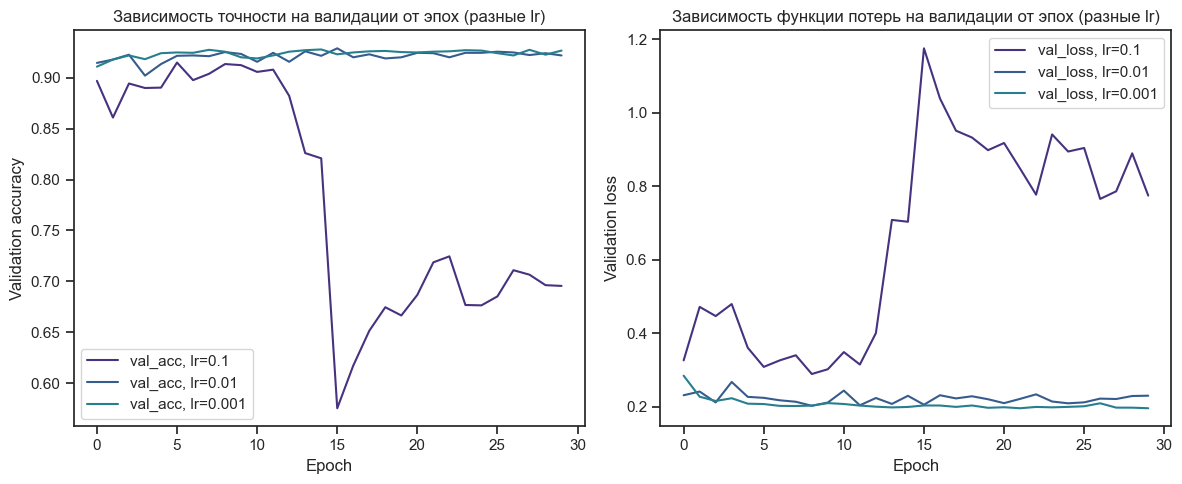

In [17]:
plt.figure(figsize=(12, 5))

# График точности на валидации
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(histories[lr].epoch, histories[lr].history["val_accuracy"], label=f"val_acc, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Зависимость точности на валидации от эпох (разные lr)")
plt.legend()

# График функции потерь на валидации
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(histories[lr].epoch, histories[lr].history["val_loss"], label=f"val_loss, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Зависимость функции потерь на валидации от эпох (разные lr)")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Интерпретация результатов и выводы

На основе проведённого эксперимента с тремя значениями `learning rate` можно сделать следующие наблюдения.

1. **Сравнение итоговой точности и функции потерь**  
   По сводной таблице в конце обучения получили:
   - при **lr = 0.1**: `test_accuracy ≈ 0.79`, `test_loss ≈ 0.56`;  
   - при **lr = 0.01**: `test_accuracy ≈ 0.93`, `test_loss ≈ 0.23`;  
   - при **lr = 0.001**: `test_accuracy ≈ 0.93`, `test_loss ≈ 0.20`.  
   Наихудшее качество показала модель с большим шагом обучения 0.1: точность заметно ниже, а функция потерь выше. Значения 0.01 и 0.001 дают сопоставимую высокую точность (около 92–93%), при этом у lr = 0.001 немного ниже итоговая функция потерь.

2. **Поведение графиков точности и потерь**  
   - Для **lr = 0.1** кривые `val_loss` и `val_accuracy` ведут себя менее стабильно: после начального улучшения наблюдаются заметные колебания и ухудшение качества на части эпох. Это говорит о том, что крупный шаг обучения приводит к "скачкам" по поверхности ошибки и мешает модели устойчиво сходиться к оптимуму.
   - Для **lr = 0.01** и **lr = 0.001** графики значительно более плавные: и `val_loss`, и `val_accuracy` постепенно улучшаются, без резких провалов. Разница между обучающей и валидационной кривыми невелика, явного сильного переобучения не наблюдается.

3. **Выбор оптимального значения learning rate**  
   - Слишком **высокий learning rate = 0.1** приводит к нестабильному обучению и более низкому качеству на тесте.
   - **Средние и малые значения (0.01 и 0.001)** обеспечивают высокую точность и устойчивое поведение графиков.  
   - В рамках данной архитектуры и числа эпох **оптимальным можно считать learning rate порядка 0.001–0.01**: шаг достаточно мал, чтобы обеспечить стабильную сходимость, и достаточно велик, чтобы модель быстро достигала хорошего качества.

**Вывод:** для задачи классификации видов бобов из датасета Dry Bean полносвязная нейросеть прямого распространения демонстрирует высокое качество (около 93% точности на тестовой выборке). Значение гиперпараметра `learning rate` существенно влияет на результат: слишком большой шаг (0.1) ухудшает точность из‑за нестабильного обучения, тогда как значения 0.01 и 0.001 позволяют модели сходиться к более выгодному минимуму функции потерь и обеспечивают лучшее обобщение на тестовой выборке.